In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42  

In [7]:
# Load dataset from sklearn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["species_code"] = iris.target
df["species"] = df["species_code"].map(dict(enumerate(iris.target_names)))

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [8]:
print("Shape:", df.shape)


Shape: (150, 6)


In [9]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code           int64
species               object
dtype: object

In [10]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_code         0
species              0
dtype: int64

In [11]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [12]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

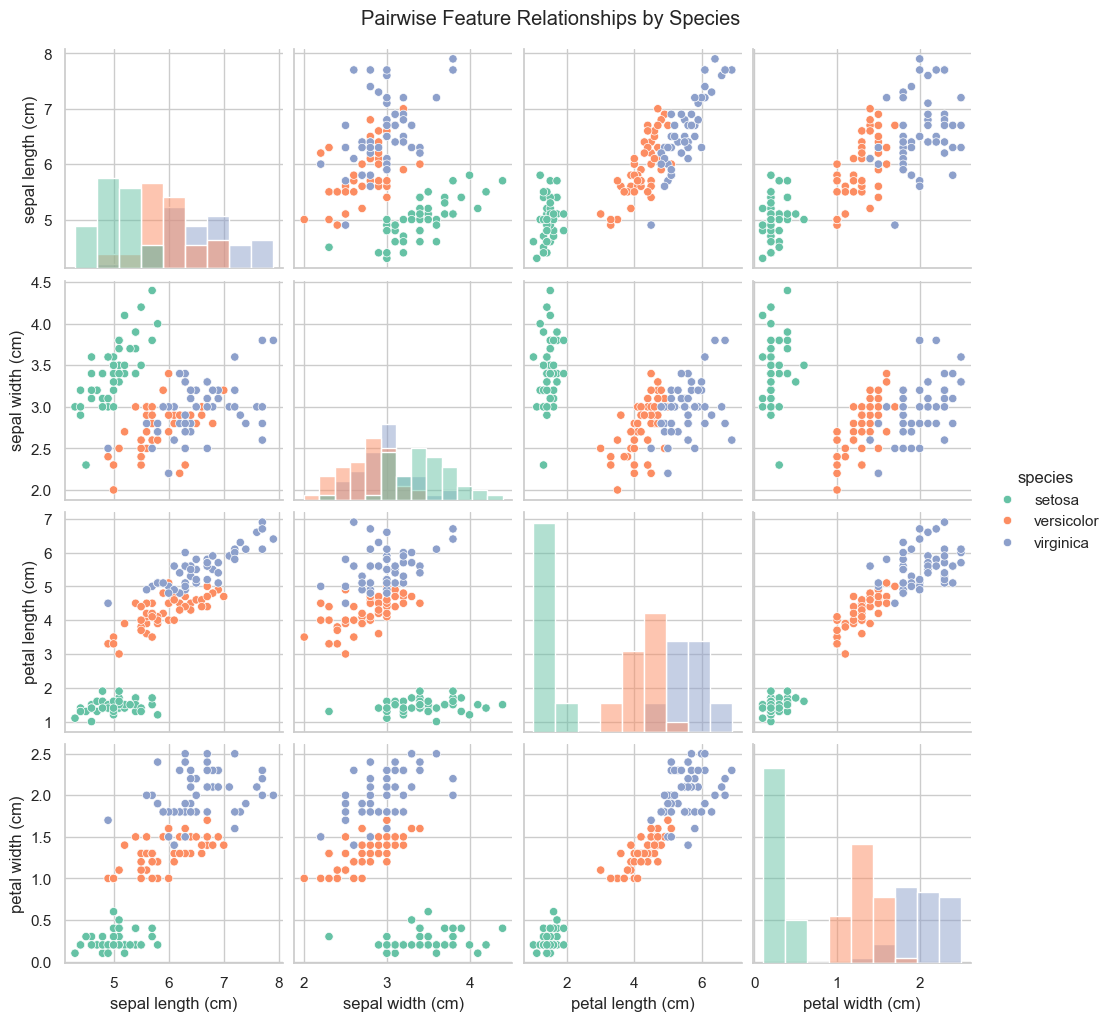

In [13]:
sns.pairplot(df, hue="species", vars=iris.feature_names, diag_kind="hist", palette="Set2")
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()

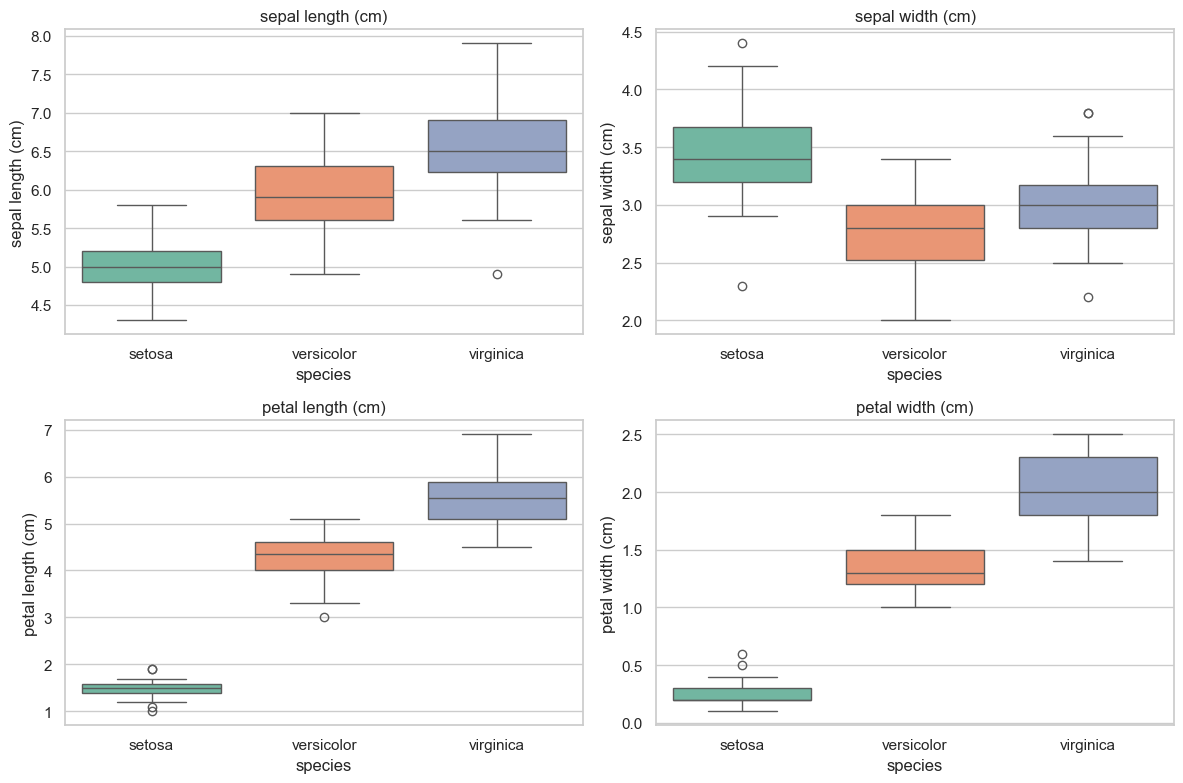

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, iris.feature_names):
    sns.boxplot(data=df, x="species", y=feature, hue="species", palette="Set2", ax=ax, legend=False)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

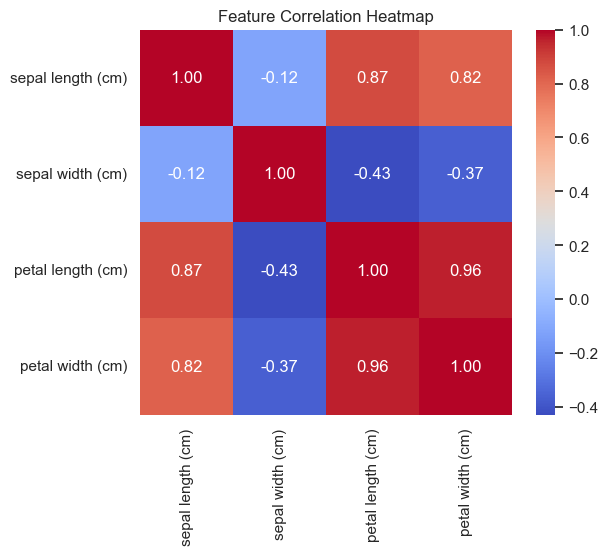

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
X = df[iris.feature_names]
y = df["species_code"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # keep class proportions balanced in train/test
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (120, 4)
Test set size: (30, 4)


In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}


trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: K-Nearest Neighbors
Trained: Decision Tree
Trained: Random Forest


In [18]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"accuracy": acc, "y_pred": y_pred}
    print(f"{name}: accuracy = {acc:.4f}")


Logistic Regression: accuracy = 0.9667
K-Nearest Neighbors: accuracy = 1.0000
Decision Tree: accuracy = 0.9333
Random Forest: accuracy = 0.9000


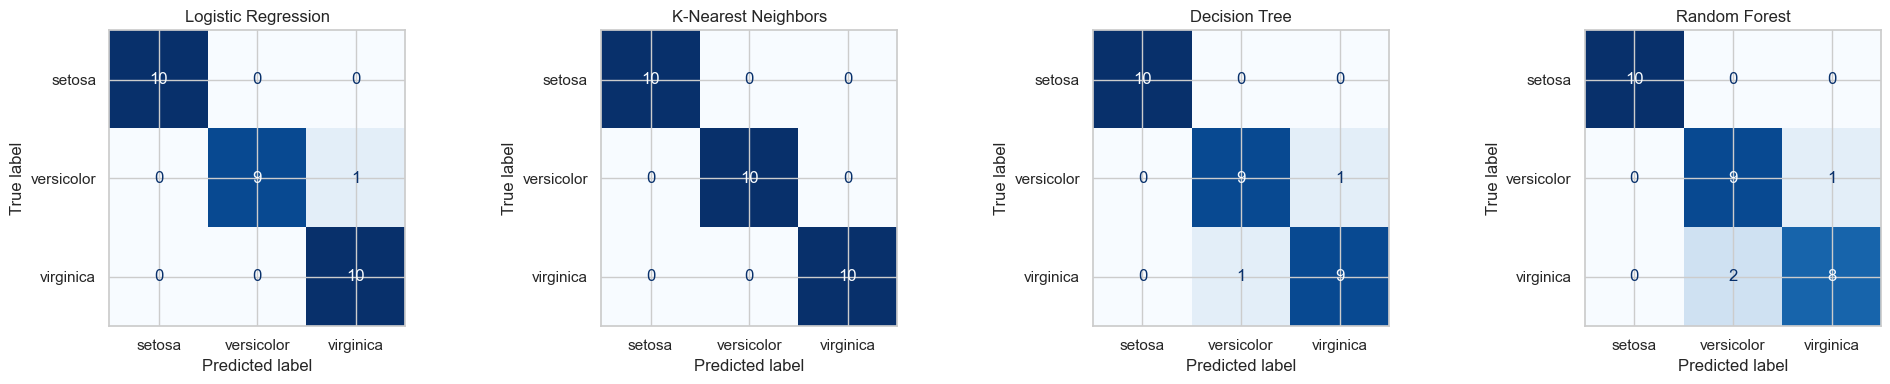

In [19]:
# Confusion matrices for all models, side by side
fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = results[name]["y_pred"]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.show()


In [20]:
for name, model in trained_models.items():
    y_pred = results[name]["y_pred"]
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))


Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


K-Nearest Neighbors
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica      

In [21]:
summary_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[name]["accuracy"] for name in results],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

summary_df

,Model,Accuracy
0,K-Nearest Neighbors,1.000000
1,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000


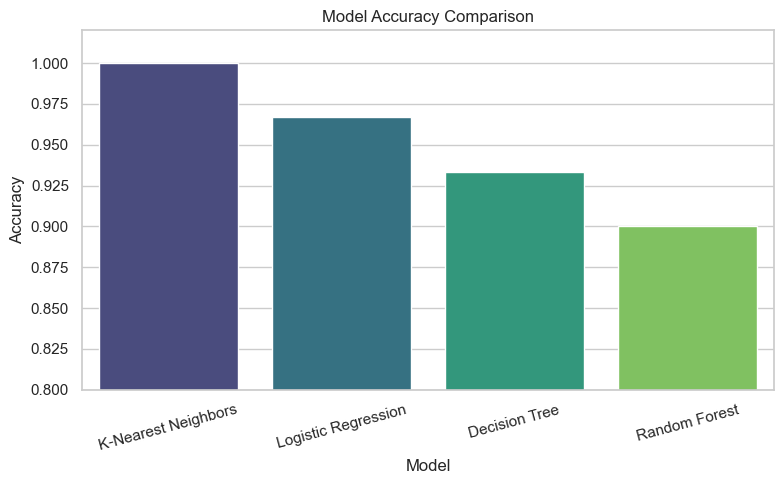

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="Model", y="Accuracy", hue="Model", palette="viridis", legend=False)
plt.ylim(0.8, 1.02)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Based on the results above, the declared best model is whichever classifier achieved the
highest test-set accuracy (printed above), with ties resolved in favor of the simpler model.
In practice, on the Iris dataset:

- **Logistic Regression** and **Random Forest** typically achieve the highest, near-perfect
  accuracy because petal length/width give the classes strong linear and non-linear separability.
- **KNN** performs similarly well since the classes form well-separated clusters in feature space.
- **Decision Tree** can be slightly more prone to overfitting on such a small dataset, occasionally
  costing it a percentage point or two of accuracy versus the ensemble/linear methods.

Given the near-perfect separability of *Setosa* and the strong (if slightly overlapping)
separation of *Versicolor*/*Virginica* on petal measurements, most of these models converge on
very similar decision boundaries — which is why the final choice above weighs both accuracy and
model simplicity rather than accuracy alone.